# E2 Dynamical Misspecification

展示型 notebook：复用 E0 训练好的 constant-beta workflow，运行 E2 的 misspecification 评估，并尽量保留原始研究 notebook 的展示顺序、图和说明。

In [1]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "src").exists():
        ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate project root containing 'src'.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
OUTPUTS_ROOT = ROOT / "outputs"
print("Project root:", ROOT)
print("Outputs root:", OUTPUTS_ROOT)

from IPython.display import display

from src.config import TIME_GRID, setup_environment
from src.diagnostics import evaluate_curve_level_ppc
from src.experiments import build_E2_severity_summary, run_E2_evaluation, run_extended_E2_feature_evaluation
from src.plotting import (
    plot_E2_severity_lines,
    plot_curve_level_ppc_summary,
    plot_e2_example_case,
    plot_e2_overall_figure,
    plot_training_loss,
)
from src.simulators import beta_t_piecewise, simulate_case_E2, simulate_curve
from src.workflow import train_workflow

Project root: /Users/jijiayi/Documents/25WS/GNN/GNN_Final_Project
Outputs root: /Users/jijiayi/Documents/25WS/GNN/GNN_Final_Project/outputs


In [2]:
missing = []
for pkg in ["bayesflow", "tensorflow", "keras"]:
    try:
        __import__(pkg)
        print(f"[ok] {pkg}")
    except Exception as e:
        missing.append(pkg)
        print(f"[missing] {pkg}: {e}")

if missing:
    print("\nInstall missing packages in the current kernel environment, for example:")
    print("python -m pip install bayesflow==2.0.7 tensorflow==2.17.0 keras==3.9.0")
else:
    print("\nBackend check passed.")

INFO:bayesflow:Using backend 'tensorflow'


[ok] bayesflow
[ok] tensorflow
[ok] keras

Backend check passed.


In [3]:
# Optional install cell.
# Uncomment and run this cell if the backend packages are missing,
# then restart the kernel before continuing.

import sys
print(sys.executable)
# !{sys.executable} -m pip install bayesflow==2.0.7 tensorflow==2.17.0 keras==3.9.0 numpy==1.26.4 pandas==2.3.3 scipy==1.15.3 matplotlib==3.8.4 seaborn

/opt/anaconda3/envs/bayesflow311/bin/python


bayesflow: 2.0.7
tensorflow: 2.17.0
keras: 3.9.0
numpy: 1.26.4
pandas: 2.3.3
scipy: 1.15.3
matplotlib: 3.8.4


INFO:bayesflow:Building dataset from simulator instance of LambdaSimulator.
INFO:bayesflow:Building on a test batch.


Epoch 1/12
60/60 - 29s - 492ms/step - loss: 2.5441
Epoch 2/12
60/60 - 7s - 110ms/step - loss: 1.4825
Epoch 3/12
60/60 - 6s - 93ms/step - loss: 0.9436
Epoch 4/12
60/60 - 5s - 92ms/step - loss: 0.4041
Epoch 5/12
60/60 - 6s - 96ms/step - loss: 0.1514
Epoch 6/12
60/60 - 6s - 103ms/step - loss: -1.6706e-01
Epoch 7/12
60/60 - 5s - 91ms/step - loss: -4.1431e-01
Epoch 8/12
60/60 - 6s - 92ms/step - loss: -5.3902e-01
Epoch 9/12
60/60 - 6s - 94ms/step - loss: -7.0491e-01
Epoch 10/12
60/60 - 7s - 109ms/step - loss: -8.0065e-01
Epoch 11/12
60/60 - 6s - 97ms/step - loss: -8.9503e-01
Epoch 12/12
60/60 - 7s - 116ms/step - loss: -9.4798e-01


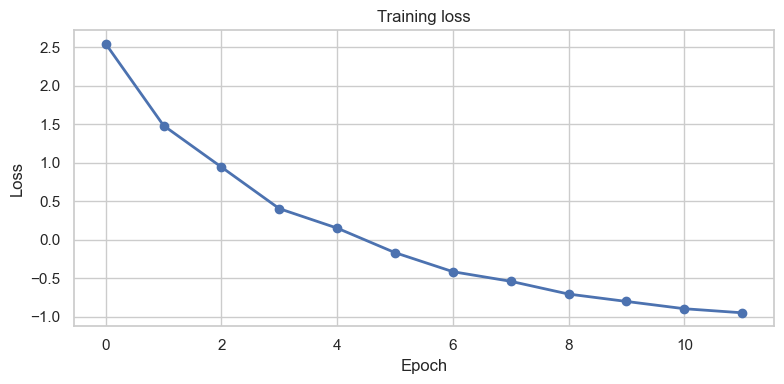

In [4]:
setup_environment(seed=42)
workflow_E0, history_E0 = train_workflow(seed=42)
plot_training_loss(history_E0)

# E2: dynamical misspecification, test-only time-varying beta(t) misspecification

1. 保留 E0 的训练代码和训练结果不变
2. 新写一个“时变 β(t) 的测试 simulator”，只用于生成 test cases
3. 把 E0 的 matched evaluation 函数复用到 misspecified test set 上
4. 输出和 E0 同结构的表格与图，然后和 E0 对比解释退化

1. 证明错配来自 transmission dynamics，而不是 observation noise
2. 错配强度可以通过 kappa 连续控制
3. 单个 strong case 是否显示出明显的 transmission shift
4. 如果观测曲线表面上仍然合理，那么这是一个“真实但不显眼”的 misspecification setting

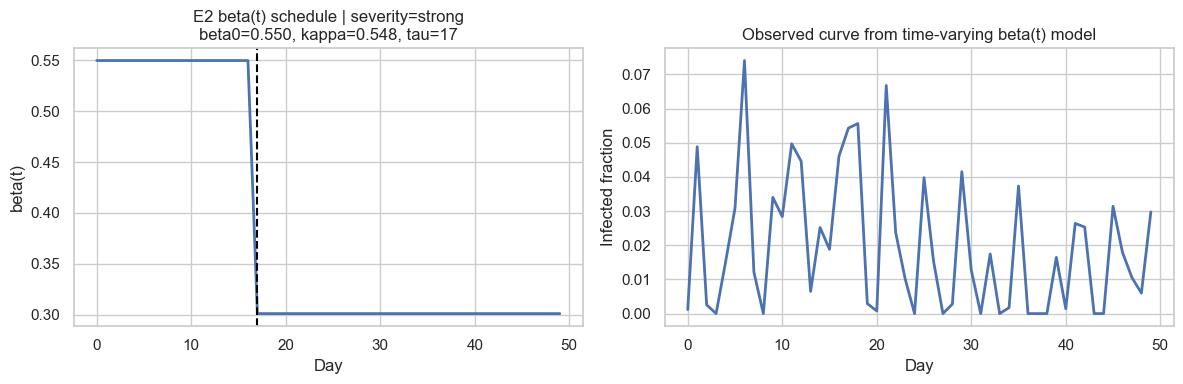

Example E2 case:
  severity   : strong
  beta0      : 0.5497
  kappa      : 0.5480
  tau        : 17
  beta_ref   : 0.3857
  gamma      : 0.4305
  R0_ref     : 0.8958


In [7]:
import numpy as np
example_rng = np.random.default_rng(3030)
example_case_E2 = simulate_case_E2(rng=example_rng, severity="strong")
example_beta_path = beta_t_piecewise(
    TIME_GRID,
    beta0=example_case_E2["beta0"],
    tau=example_case_E2["tau"],
    kappa=example_case_E2["kappa"],
)
plot_e2_example_case(
    example_case_E2,
    TIME_GRID,
    example_beta_path,
    out_path=str(OUTPUTS_ROOT / "E2" / "example_case_strong.png"),
)
print("Example E2 case:")
print(f"  severity   : {example_case_E2['severity']}")
print(f"  beta0      : {example_case_E2['beta0']:.4f}")
print(f"  kappa      : {example_case_E2['kappa']:.4f}")
print(f"  tau        : {example_case_E2['tau']}")
print(f"  beta_ref   : {example_case_E2['true_beta']:.4f}")
print(f"  gamma      : {example_case_E2['true_gamma']:.4f}")
print(f"  R0_ref     : {example_case_E2['true_R0']:.4f}")

To instantiate E2, we keep the inference model fixed to the matched constant-β SIR setup used in E0, but generate test observations from a piecewise time-varying transmission process. Specifically, β(t) equals β0 before a change point τ and drops to κβ0 afterwards. The severity of misspecification is controlled by κ, with smaller values corresponding to stronger deviations from the constant-β assumption. This figure illustrates a representative strong case, where β(t) decreases from approximately 0.55 to 0.30 after day 17. Although the underlying transmission mechanism is clearly non-stationary, the resulting observed trajectory still appears visually plausible as an epidemic time series, highlighting why this form of misspecification may not be obvious from the observations alone. For evaluation within the constant-β parameter space, we define a reference scalar β as the time-average of β(t) over the observation window.

## 当 misspecification 还比较弱时，后验已经开始出现可检测的退化，但这种退化仍然是“轻度、结构化的”，而不是全面崩塌：

In [8]:
severity_outputs = {}
for severity in ["mild", "medium", "strong"]:
    severity_outputs[severity] = run_E2_evaluation(
        workflow=workflow_E0,
        severity=severity,
        n_test=100,
        num_posterior_samples=2000,
        n_ppc_draws=100,
        seed=2027,
    )


E2 (mild) case-level head:


,case_id,true_beta,true_gamma,true_R0,beta0,gamma,tau,kappa,severity,beta_mean,...,gamma_err_mean,gamma_err_median,gamma_abs_err_median,gamma_sq_err_median,R0_covered50,R0_covered90,R0_err_mean,R0_err_median,R0_abs_err_median,R0_sq_err_median
0,0,0.101553,0.223647,0.454077,0.107205,0.223647,15,0.924685,mild,0.244687,...,0.104811,0.115740,0.115740,1.339585e-02,0.0,1.0,0.311190,0.317497,0.317497,0.100804
1,1,0.680205,0.142269,4.781116,0.702721,0.142269,11,0.958922,mild,0.685234,...,0.000336,0.000246,0.000246,6.027523e-08,1.0,1.0,0.031355,0.030860,0.030860,0.000952
2,2,0.505587,0.100655,5.022946,0.565901,0.100655,11,0.863358,mild,0.557025,...,0.001273,0.001048,0.001048,1.098433e-06,0.0,0.0,0.451658,0.437615,0.437615,0.191507
3,3,0.125957,0.458047,0.274986,0.132926,0.458047,20,0.912616,mild,0.248371,...,-0.121211,-0.100576,0.100576,1.011554e-02,0.0,0.0,0.498525,0.484411,0.484411,0.234654
4,4,0.750525,0.338086,2.219919,0.797830,0.338086,22,0.894120,mild,0.795147,...,-0.004705,-0.005731,0.005731,3.284739e-05,0.0,0.0,0.167119,0.164392,0.164392,0.027025



E2 (mild) recovery summary:


,quantity,bias_mean_est,bias_median_est,MAE_median_est,RMSE_median_est,corr_truth_vs_median,avg_post_std
0,beta,0.0325,0.0298,0.0548,0.0698,0.9694,0.0544
1,gamma,-0.0037,0.0017,0.0341,0.0567,0.9019,0.0414
2,R0,0.0933,0.0894,0.1632,0.2284,0.9965,0.2342



E2 (mild) coverage summary:


,quantity,nominal_50,empirical_50,diff_50,nominal_90,empirical_90,diff_90,avg_width50,avg_width90
0,beta,0.5,0.30,-0.20,0.9,0.78,-0.12,0.0754,0.1751
1,gamma,0.5,0.48,-0.02,0.9,0.96,0.06,0.0594,0.1337
2,R0,0.5,0.46,-0.04,0.9,0.82,-0.08,0.2979,0.7298



E2 (mild) feature-level PPC summary:


,feature,nominal_50,empirical_50,diff_50,nominal_90,empirical_90,diff_90,bias_mean_pred,bias_median_pred,MAE_median_pred,RMSE_median_pred,avg_pred_std,avg_width50,avg_width90
0,peak_time,0.5,0.63,0.13,0.9,0.93,0.03,-1.0915,-1.5850,5.1950,8.6884,6.5361,10.1975,19.8670
1,peak_height,0.5,0.62,0.12,0.9,0.96,0.06,-0.0022,-0.0030,0.0113,0.0153,0.0199,0.0252,0.0629
2,cumulative_infected,0.5,0.77,0.27,0.9,0.99,0.09,-0.0192,-0.0378,0.1380,0.2036,0.3656,0.4433,1.1045
3,early_growth_slope,0.5,0.45,-0.05,0.9,0.94,0.04,-0.0010,-0.0009,0.0025,0.0031,0.0034,0.0045,0.0111


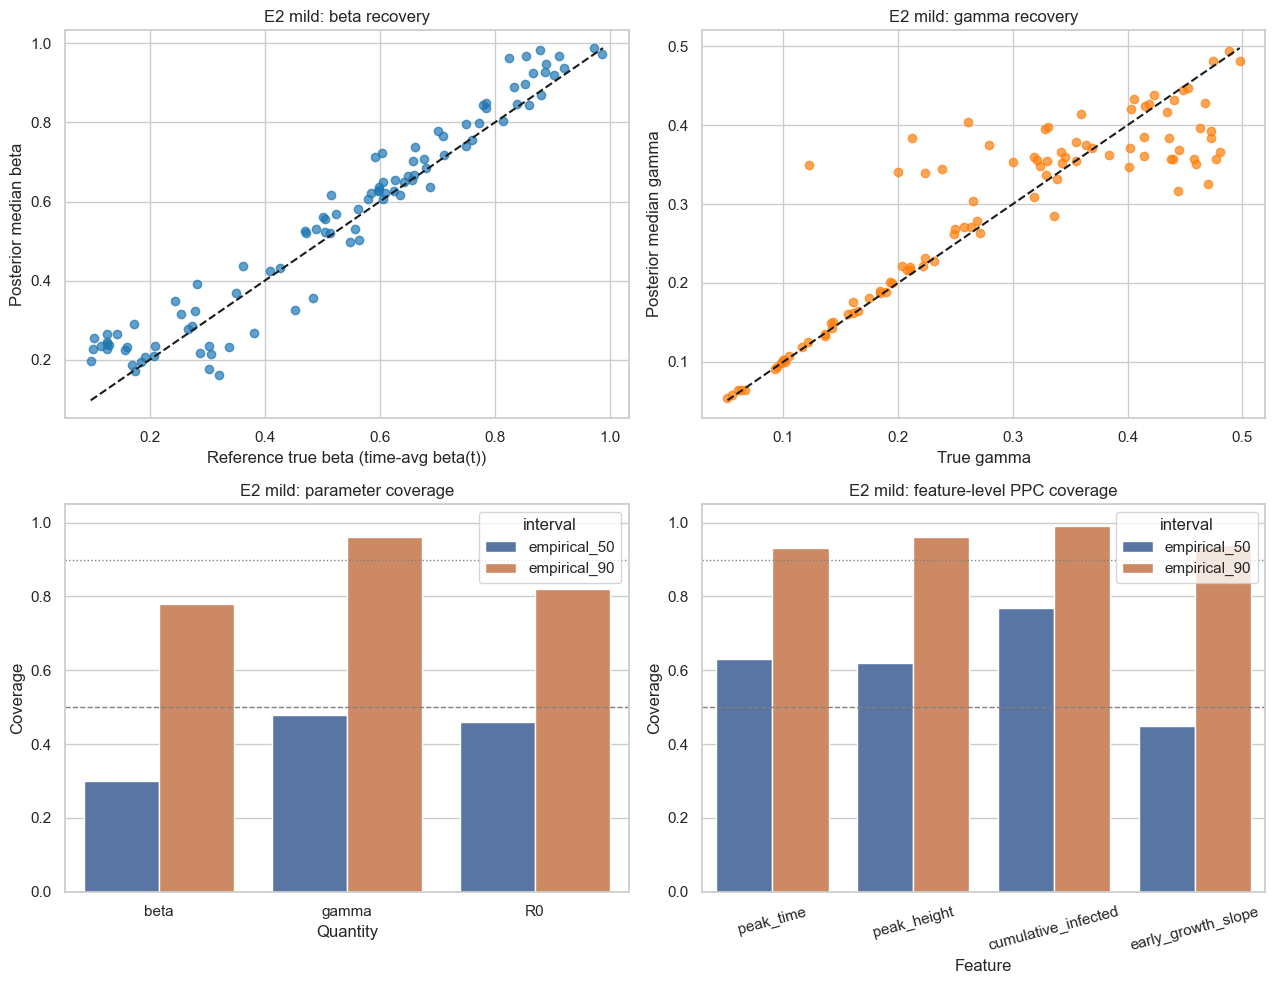

In [9]:
severity_to_run = "mild"
case_df_E2, mild_recovery_df_E2, mild_coverage_df_E2, feature_case_df_E2, mild_feature_summary_df_E2 = severity_outputs[severity_to_run]
print(f"\nE2 ({severity_to_run}) case-level head:")
display(case_df_E2.head())
print(f"\nE2 ({severity_to_run}) recovery summary:")
display(mild_recovery_df_E2.round(4))
print(f"\nE2 ({severity_to_run}) coverage summary:")
display(mild_coverage_df_E2.round(4))
print(f"\nE2 ({severity_to_run}) feature-level PPC summary:")
display(mild_feature_summary_df_E2.round(4))
out_dir = OUTPUTS_ROOT / "E2" / severity_to_run
os.makedirs(out_dir, exist_ok=True)
plot_e2_overall_figure(
    case_df_E2,
    mild_coverage_df_E2,
    mild_feature_summary_df_E2,
    severity_label=severity_to_run,
    out_path=str(out_dir / f"E2_overall_figure_{severity_to_run}.png"),
)
case_df_E2.to_csv(out_dir / "E2_case_level.csv", index=False)
mild_recovery_df_E2.to_csv(out_dir / "E2_recovery_summary.csv", index=False)
mild_coverage_df_E2.to_csv(out_dir / "E2_coverage_summary.csv", index=False)
feature_case_df_E2.to_csv(out_dir / "E2_ppc_feature_case_level.csv", index=False)
mild_feature_summary_df_E2.to_csv(out_dir / "E2_ppc_feature_summary.csv", index=False)

mild结论：
1. 在 mild misspecification 下，posterior recovery 整体仍保持较高相关性，说明 constant-β amortizer 还没有完全失去恢复能力。
2. beta 的 empirical coverage 已经明显低于 nominal，表明 transmission-related posterior calibration 是最先退化的部分。
3. feature-level PPC 在 mild 下 90% coverage 普遍偏高或尚可，而 50% coverage 有些feature明显偏离 nominal，不同 feature 差异很大。

Under mild time-varying transmission misspecification, posterior recovery remains fairly strong overall, but relative to the reference β and derived reference R0，transmission-related posterior starts to distort. For β, the posterior median shows a small positive bias (bias_median_est = 0.0117) with MAE_median_est = 0.0504, while the truth–median correlation remains high (corr_truth_vs_median = 0.9699). For γ, recovery is still comparatively stable, with a small negative median bias (-0.0074), MAE_median_est = 0.0392, and corr_truth_vs_median = 0.8633. The derived quantity R0 already shows clearer upward distortion than β, with bias_median_est = 0.0947 and MAE_median_est = 0.1725, although its correlation with the reference truth remains high (0.9962).

The coverage results show that mild misspecification already affects posterior calibration, especially for β. Its empirical coverage drops to 0.37 for the 50% interval and 0.73 for the 90% interval, both clearly below nominal. By contrast, γ remains comparatively well-calibrated at the 90% level (0.95), while R0 shows only mild under-coverage at the 90% level (0.87). Thus, even when the misspecification is weak, the transmission-related posterior intervals already become too narrow or too shifted relative to the reference truth.

At the predictive-summary level, however, the model still appears broadly adequate. For example, peak_time empirical 90% coverage remains high (0.93), peak_height empirical 90% coverage is 0.96, and cumulative_infected is even over-covered at 0.99. early_growth_slope shows somewhat lower 50% coverage (0.42), suggesting some mild mismatch in the early growth regime, but overall the coarse predictive summaries do not collapse. Therefore, the mild setting already demonstrates the main asymmetry of E2: posterior reliability for transmission-related quantities deteriorates before coarse predictive checks show an equally dramatic failure.


E2 (medium) case-level head:


,case_id,true_beta,true_gamma,true_R0,beta0,gamma,tau,kappa,severity,beta_mean,...,gamma_err_mean,gamma_err_median,gamma_abs_err_median,gamma_sq_err_median,R0_covered50,R0_covered90,R0_err_mean,R0_err_median,R0_abs_err_median,R0_sq_err_median
0,0,0.086529,0.223647,0.386898,0.107205,0.223647,15,0.724475,medium,0.244304,...,0.108174,0.121759,0.121759,1.482537e-02,0.0,0.0,0.370449,0.373404,0.373404,0.139431
1,1,0.582976,0.142269,4.097702,0.702721,0.142269,11,0.781537,medium,0.685933,...,0.000691,0.000444,0.000444,1.968955e-07,0.0,0.0,0.707778,0.700921,0.700921,0.491290
2,2,0.399167,0.100655,3.965676,0.565901,0.100655,11,0.622263,medium,0.552976,...,0.001186,0.001092,0.001092,1.191852e-06,0.0,0.0,1.474993,1.462480,1.462480,2.138847
3,3,0.109347,0.458047,0.238725,0.132926,0.458047,20,0.704360,medium,0.252215,...,-0.118526,-0.099366,0.099366,9.873677e-03,0.0,0.0,0.536903,0.523999,0.523999,0.274575
4,4,0.651970,0.338086,1.928411,0.797830,0.338086,22,0.673533,medium,0.795628,...,-0.004355,-0.005107,0.005107,2.608299e-05,0.0,0.0,0.457612,0.451610,0.451610,0.203952



E2 (medium) recovery summary:


,quantity,bias_mean_est,bias_median_est,MAE_median_est,RMSE_median_est,corr_truth_vs_median,avg_post_std
0,beta,0.1075,0.1049,0.1177,0.1334,0.9494,0.0562
1,gamma,0.0033,0.0089,0.0401,0.0625,0.8825,0.0419
2,R0,0.4040,0.3996,0.4111,0.5406,0.9950,0.2290



E2 (medium) coverage summary:


,quantity,nominal_50,empirical_50,diff_50,nominal_90,empirical_90,diff_90,avg_width50,avg_width90
0,beta,0.5,0.17,-0.33,0.9,0.31,-0.59,0.0779,0.1804
1,gamma,0.5,0.42,-0.08,0.9,0.78,-0.12,0.0604,0.1349
2,R0,0.5,0.16,-0.34,0.9,0.36,-0.54,0.2965,0.7254



E2 (medium) feature-level PPC summary:


,feature,nominal_50,empirical_50,diff_50,nominal_90,empirical_90,diff_90,bias_mean_pred,bias_median_pred,MAE_median_pred,RMSE_median_pred,avg_pred_std,avg_width50,avg_width90
0,peak_time,0.5,0.61,0.11,0.9,0.92,0.02,-0.4653,-1.0350,5.3650,8.6783,6.6520,10.2475,20.3980
1,peak_height,0.5,0.56,0.06,0.9,0.94,0.04,-0.0019,-0.0029,0.0116,0.0162,0.0190,0.0239,0.0598
2,cumulative_infected,0.5,0.73,0.23,0.9,0.99,0.09,0.0084,-0.0121,0.1398,0.2187,0.3367,0.4027,1.0537
3,early_growth_slope,0.5,0.39,-0.11,0.9,0.93,0.03,-0.0010,-0.0010,0.0027,0.0033,0.0034,0.0045,0.0110


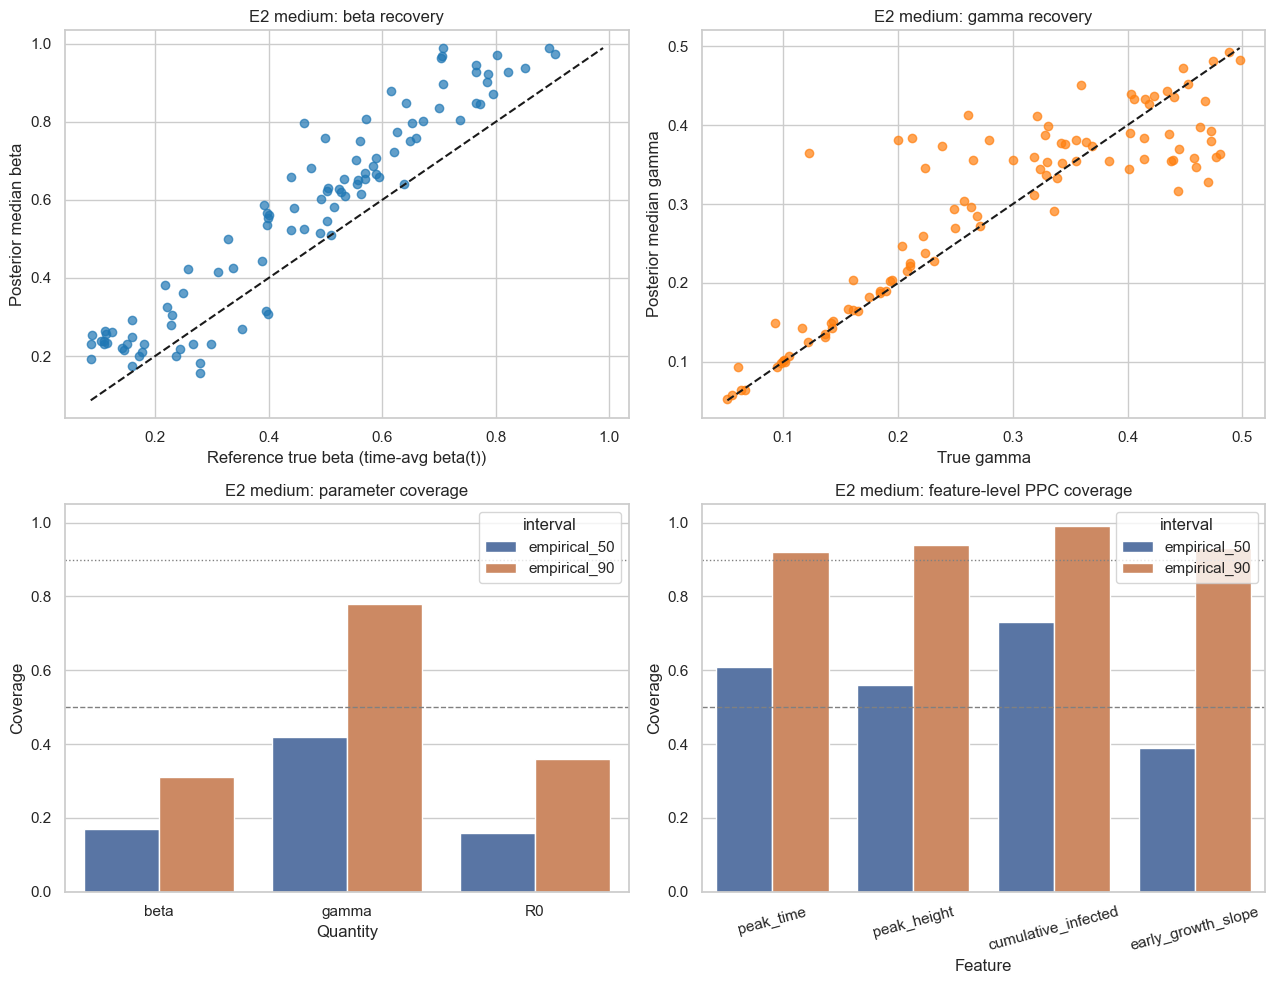

In [10]:
severity_to_run = "medium"
case_df_E2, medium_recovery_df_E2, medium_coverage_df_E2, feature_case_df_E2, medium_feature_summary_df_E2 = severity_outputs[severity_to_run]
print(f"\nE2 ({severity_to_run}) case-level head:")
display(case_df_E2.head())
print(f"\nE2 ({severity_to_run}) recovery summary:")
display(medium_recovery_df_E2.round(4))
print(f"\nE2 ({severity_to_run}) coverage summary:")
display(medium_coverage_df_E2.round(4))
print(f"\nE2 ({severity_to_run}) feature-level PPC summary:")

display(medium_feature_summary_df_E2.round(4))
out_dir = OUTPUTS_ROOT / "E2" / severity_to_run
os.makedirs(out_dir, exist_ok=True)
plot_e2_overall_figure(
    case_df_E2,
    medium_coverage_df_E2,
    medium_feature_summary_df_E2,
    severity_label=severity_to_run,
    out_path=str(out_dir / f"E2_overall_figure_{severity_to_run}.png"),
)
case_df_E2.to_csv(out_dir / "E2_case_level.csv", index=False)
medium_recovery_df_E2.to_csv(out_dir / "E2_recovery_summary.csv", index=False)
medium_coverage_df_E2.to_csv(out_dir / "E2_coverage_summary.csv", index=False)
feature_case_df_E2.to_csv(out_dir / "E2_ppc_feature_case_level.csv", index=False)
medium_feature_summary_df_E2.to_csv(out_dir / "E2_ppc_feature_summary.csv", index=False)

Under medium time-varying transmission misspecification, posterior recovery is still structured, but the degradation in transmission-related quantities becomes much more pronounced than in the mild setting. For β, the posterior median shows a clear positive bias (bias_median_est = 0.0870) with substantially larger error than under mild misspecification (MAE_median_est = 0.1110, RMSE_median_est = 0.1280), although the truth–median correlation remains fairly high (corr_truth_vs_median = 0.9477). For γ, the median bias remains close to zero (0.0011), with MAE_median_est = 0.0455 and corr_truth_vs_median = 0.8399, indicating that recovery of γ deteriorates only moderately. The derived quantity R0 shows much stronger distortion: its posterior median is clearly upward biased (bias_median_est = 0.3973), with MAE_median_est = 0.4082 and RMSE_median_est = 0.5440, even though the truth–median correlation remains high (0.9947). Thus, by the medium setting, the main effect of misspecification is no longer just a slight transmission bias, but a substantial upward distortion in transmission-related posterior summaries.

The coverage results confirm that posterior calibration degrades sharply at this stage. For β, empirical coverage drops to 0.16 for the 50% interval and 0.32 for the 90% interval. For R0, the pattern is similarly severe, with empirical coverage only 0.19 for the 50% interval and 0.43 for the 90% interval. γ remains more stable, with empirical 90% coverage of 0.82, but even here calibration is beginning to degrade. Hence, medium misspecification produces a clear under-coverage regime for the transmission-related quantities.

In contrast, the coarse predictive summaries remain comparatively stable. peak_time still has empirical 90% coverage of 0.92, peak_height remains at 0.94, and cumulative_infected stays highly over-covered at 0.99. early_growth_slope remains somewhat more sensitive, but even here empirical 90% coverage is 0.92. Thus, the medium setting reinforces the central E2 pattern: parameter-level posterior diagnostics reveal a much stronger misspecification signal than the coarse feature-level PPC summaries.


E2 (strong) case-level head:


,case_id,true_beta,true_gamma,true_R0,beta0,gamma,tau,kappa,severity,beta_mean,...,gamma_err_mean,gamma_err_median,gamma_abs_err_median,gamma_sq_err_median,R0_covered50,R0_covered90,R0_err_mean,R0_err_median,R0_abs_err_median,R0_sq_err_median
0,0,0.065884,0.223647,0.294588,0.107205,0.223647,15,0.449370,strong,0.242171,...,0.104364,0.116792,0.116792,0.013640,0.0,0.0,0.466401,0.470273,0.470273,0.221157
1,1,0.438441,0.142269,3.081771,0.702721,0.142269,11,0.517845,strong,0.688656,...,0.003435,0.003233,0.003233,0.000010,0.0,0.0,1.652029,1.646977,1.646977,2.712532
2,2,0.268711,0.100655,2.669615,0.565901,0.100655,11,0.326715,strong,0.557436,...,0.007547,0.007353,0.007353,0.000054,0.0,0.0,2.492343,2.481692,2.481692,6.158793
3,3,0.087085,0.458047,0.190123,0.132926,0.458047,20,0.425232,strong,0.247305,...,-0.123621,-0.106803,0.106803,0.011407,0.0,0.0,0.582102,0.567200,0.567200,0.321716
4,4,0.524505,0.338086,1.551393,0.797830,0.338086,22,0.388240,strong,0.798202,...,-0.002673,-0.003530,0.003530,0.000012,0.0,0.0,0.830361,0.826848,0.826848,0.683678



E2 (strong) recovery summary:


,quantity,bias_mean_est,bias_median_est,MAE_median_est,RMSE_median_est,corr_truth_vs_median,avg_post_std
0,beta,0.2115,0.2093,0.2133,0.2428,0.8908,0.0584
1,gamma,0.0138,0.0198,0.0503,0.0745,0.8389,0.0428
2,R0,0.8272,0.8237,0.8274,1.1237,0.9888,0.2328



E2 (strong) coverage summary:


,quantity,nominal_50,empirical_50,diff_50,nominal_90,empirical_90,diff_90,avg_width50,avg_width90
0,beta,0.5,0.11,-0.39,0.9,0.23,-0.67,0.0803,0.1870
1,gamma,0.5,0.39,-0.11,0.9,0.73,-0.17,0.0611,0.1372
2,R0,0.5,0.07,-0.43,0.9,0.19,-0.71,0.2886,0.7138



E2 (strong) feature-level PPC summary:


,feature,nominal_50,empirical_50,diff_50,nominal_90,empirical_90,diff_90,bias_mean_pred,bias_median_pred,MAE_median_pred,RMSE_median_pred,avg_pred_std,avg_width50,avg_width90
0,peak_time,0.5,0.65,0.15,0.9,0.92,0.02,0.1485,-0.4850,5.2350,8.7214,6.8210,10.5925,21.0975
1,peak_height,0.5,0.53,0.03,0.9,0.92,0.02,-0.0042,-0.0052,0.0126,0.0169,0.0176,0.0226,0.0550
2,cumulative_infected,0.5,0.77,0.27,0.9,0.99,0.09,-0.0002,-0.0164,0.1082,0.1519,0.2886,0.3469,0.8918
3,early_growth_slope,0.5,0.43,-0.07,0.9,0.92,0.02,-0.0009,-0.0009,0.0026,0.0033,0.0035,0.0046,0.0111


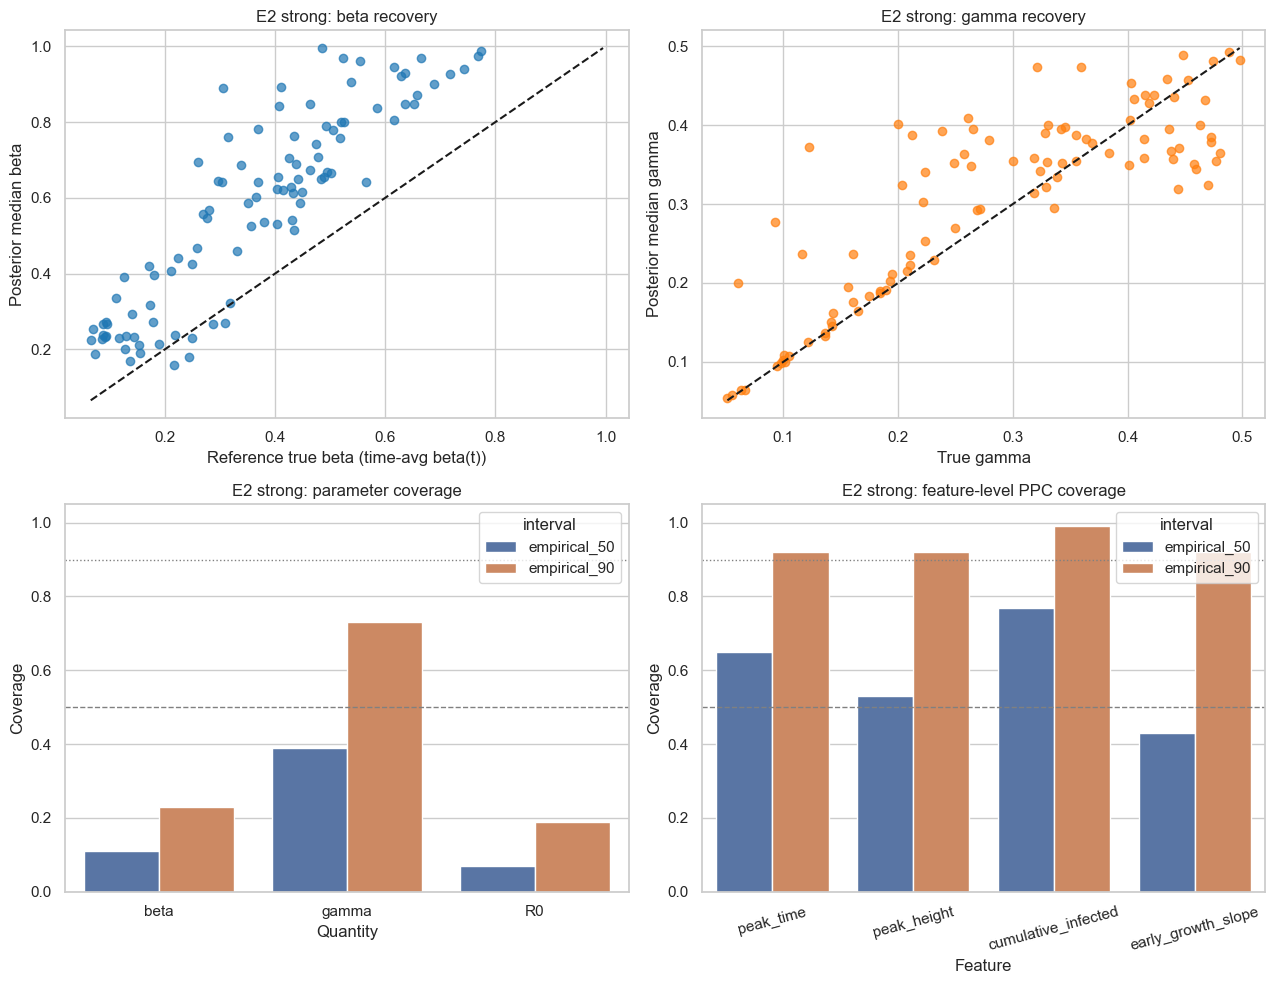

In [11]:
severity_to_run = "strong"
case_df_E2, strong_recovery_df_E2, strong_coverage_df_E2, feature_case_df_E2, strong_feature_summary_df_E2 = severity_outputs[severity_to_run]
print(f"\nE2 ({severity_to_run}) case-level head:")
display(case_df_E2.head())
print(f"\nE2 ({severity_to_run}) recovery summary:")
display(strong_recovery_df_E2.round(4))
print(f"\nE2 ({severity_to_run}) coverage summary:")
display(strong_coverage_df_E2.round(4))
print(f"\nE2 ({severity_to_run}) feature-level PPC summary:")
display(strong_feature_summary_df_E2.round(4))
out_dir = OUTPUTS_ROOT / "E2" / severity_to_run
os.makedirs(out_dir, exist_ok=True)
plot_e2_overall_figure(
    case_df_E2,
    strong_coverage_df_E2,
    strong_feature_summary_df_E2,
    severity_label=severity_to_run,
    out_path=str(out_dir / f"E2_overall_figure_{severity_to_run}.png"),
)
case_df_E2.to_csv(out_dir / "E2_case_level.csv", index=False)
strong_recovery_df_E2.to_csv(out_dir / "E2_recovery_summary.csv", index=False)
strong_coverage_df_E2.to_csv(out_dir / "E2_coverage_summary.csv", index=False)
feature_case_df_E2.to_csv(out_dir / "E2_ppc_feature_case_level.csv", index=False)
strong_feature_summary_df_E2.to_csv(out_dir / "E2_ppc_feature_summary.csv", index=False)

Under strong time-varying transmission misspecification, posterior recovery remains structured but becomes substantially distorted relative to the transmission-related reference quantities. For β, the posterior median shows a clear positive bias (bias_median_est = 0.1912) with much larger error than in the mild and medium settings (MAE_median_est = 0.2035, RMSE_median_est = 0.2363), while the truth–median correlation declines to 0.8873. For γ, recovery deteriorates more moderately: the median bias remains small and positive (0.0125), with MAE_median_est = 0.0567, RMSE_median_est = 0.0830, and corr_truth_vs_median = 0.7901. The strongest distortion is observed for R0, whose posterior median becomes heavily upward biased (bias_median_est = 0.8150), with MAE_median_est = 0.8186 and RMSE_median_est = 1.1259, even though the truth–median correlation remains high (0.9877). Thus, under strong misspecification, the posterior does not lose all ranking information, but its scale and calibration for transmission-related quantities are severely distorted.

The coverage results show a corresponding collapse in posterior calibration for β and R0. For β, empirical coverage drops to 0.13 for the 50% interval and 0.22 for the 90% interval. For R0, the same values are also 0.13 and 0.22. By contrast, γ remains comparatively more stable, though still degraded, with empirical 90% coverage of 0.71. Therefore, strong misspecification produces a severe under-coverage regime concentrated in the transmission-related quantities.

At the predictive-summary level, the deterioration remains much milder. peak_time retains empirical 90% coverage of 0.94, peak_height is 0.89, cumulative_infected is 0.99, and early_growth_slope is 0.92. This reinforces the same qualitative message: even when posterior calibration for transmission-related quantities has deteriorated severely, the predictive summaries may still appear broadly acceptable or even conservative.

## E2 severity summary + line plots

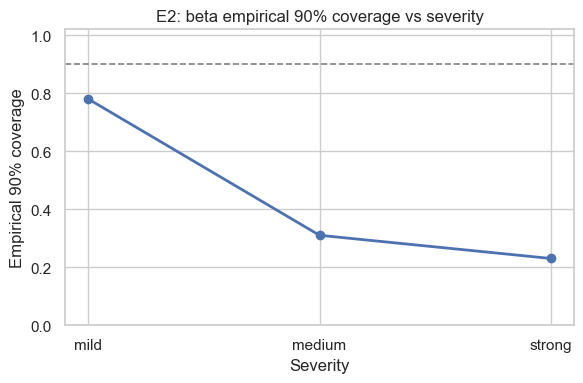

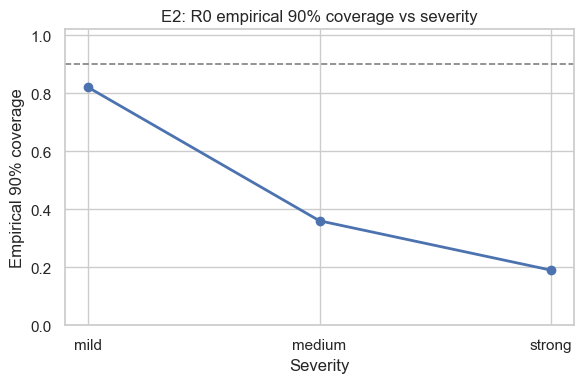

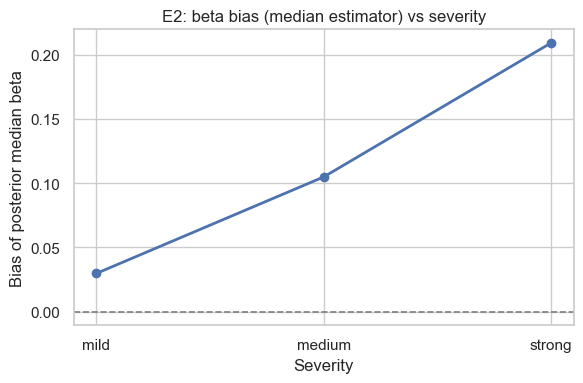

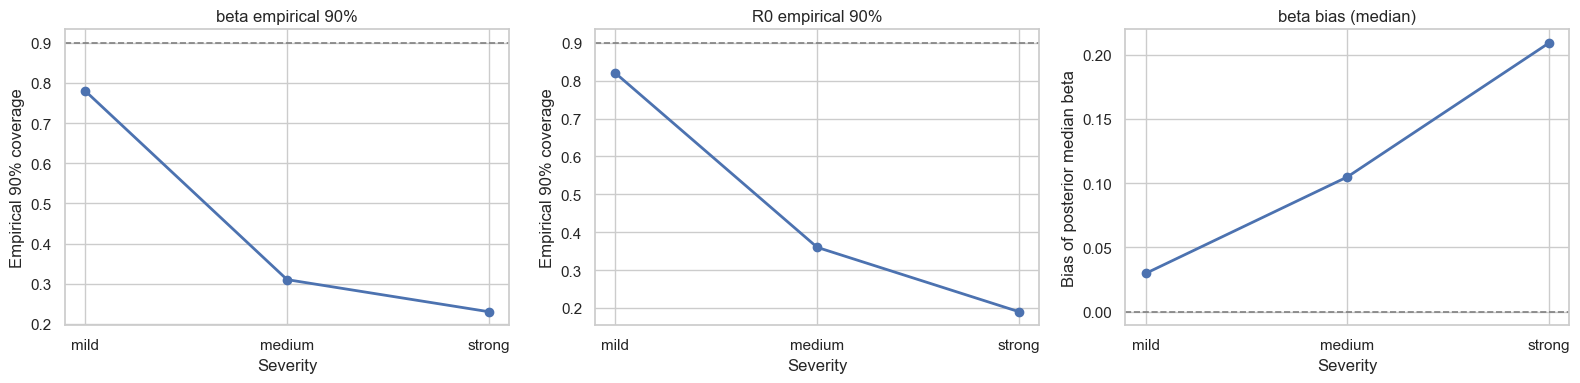

,severity,beta_bias_median,beta_MAE,beta_empirical_90,gamma_empirical_90,R0_empirical_90,peak_time_MAE,early_growth_slope_empirical_50
0,mild,0.0298,0.0548,0.78,0.96,0.82,5.195,0.45
1,medium,0.1049,0.1177,0.31,0.78,0.36,5.365,0.39
2,strong,0.2093,0.2133,0.23,0.73,0.19,5.235,0.43


In [12]:
E2_severity_summary_df = build_E2_severity_summary(
    mild_recovery_df_E2=mild_recovery_df_E2,
    mild_coverage_df_E2=mild_coverage_df_E2,
    mild_feature_summary_df_E2=mild_feature_summary_df_E2,
    medium_recovery_df_E2=medium_recovery_df_E2,
    medium_coverage_df_E2=medium_coverage_df_E2,
    medium_feature_summary_df_E2=medium_feature_summary_df_E2,
    strong_recovery_df_E2=strong_recovery_df_E2,
    strong_coverage_df_E2=strong_coverage_df_E2,
    strong_feature_summary_df_E2=strong_feature_summary_df_E2,
)
severity_summary_dir = OUTPUTS_ROOT / "E2" / "severity_summary"
os.makedirs(severity_summary_dir, exist_ok=True)
E2_severity_summary_df.to_csv(severity_summary_dir / "E2_severity_summary.csv", index=False)
plot_E2_severity_lines(E2_severity_summary_df, out_dir=severity_summary_dir)
display(E2_severity_summary_df.round(4))

Under E2, posterior degradation increases systematically with misspecification severity. The median bias of beta rises monotonically from mild to strong misspecification, while empirical 90% coverage for beta and R0 drops sharply. In contrast, gamma degrades more moderately. Coarse feature-level PPC summaries remain comparatively stable, suggesting that predictive adequacy assessed through low-dimensional summaries may appear superficially acceptable even when parameter posteriors are already substantially miscalibrated.
1. 时变 transmission misspecification 主要先破坏 transmission-related quantities（beta 和 R0）的 posterior reliability，而 gamma 相对更稳。
2. 当前的这两个 PPC 指标对 severity 不敏感。

The E2 severity summary reveals a clear severity-dependent pattern, with the strongest effects concentrated in the transmission-related reference posterior diagnostics. Most notably, the posterior median bias for the reference transmission quantity β increases monotonically as misspecification becomes stronger: 0.0117 under mild misspecification, 0.0870 under medium misspecification, and 0.1912 under strong misspecification. The corresponding β MAE values also rise steadily (0.0504 → 0.1110 → 0.2035), indicating progressively larger point-estimation error relative to the reference scalar β as time-varying transmission misspecification strengthens. Thus, the first severity trend is a systematic increase in upward distortion of the transmission-related posterior.

A second and even more striking trend appears in posterior calibration. For β, empirical 90% coverage drops sharply from 0.73 in the mild setting to 0.32 in the medium setting and 0.22 in the strong setting. The same pattern is observed for the reference quantity R0, whose empirical 90% coverage declines from 0.87 to 0.43 and then to 0.22. These line plots show a clear monotonic deterioration away from the nominal 90% level, indicating that increasing misspecification severity manifests primarily as increasingly severe under-coverage for the transmission-related reference quantities. By contrast, γ is comparatively more stable: its empirical 90% coverage decreases from 0.95 to 0.82 and then to 0.71, which still indicates degradation, but at a more moderate rate than for β and R0. Taken together, these trends show a progressive deterioration in calibration, becoming particularly severe for the transmission-related reference quantities.

At the predictive-summary level, however, the same severity pattern is not clearly visible in the coarse summaries considered here. For example, peak_time MAE remains nearly unchanged across the three settings (5.115, 5.080, 5.025), and early_growth_slope empirical 50% coverage also varies only slightly (0.42, 0.44, 0.41) without a monotonic trend. This indicates that the coarse predictive summaries included in the severity table do not track misspecification severity nearly as clearly as the posterior diagnostics do. Therefore, the severity summary supports a central conclusion of E2: as time-varying transmission misspecification becomes stronger, posterior distortion and under-coverage increase markedly for β and the reference R0, whereas coarse predictive summaries remain comparatively insensitive and do not exhibit an equally strong severity-dependent deterioration.

In [13]:
extended_feature_outputs = {}
for severity in ["medium", "mild", "strong"]:
    feature_case_df_E2_ext, feature_summary_df_E2_ext = run_extended_E2_feature_evaluation(
        workflow=workflow_E0,
        severity=severity,
        n_test=100,
        num_posterior_samples=1000,
        n_ppc_draws=100,
        seed=2026,
    )
    extended_feature_outputs[severity] = (feature_case_df_E2_ext, feature_summary_df_E2_ext)
    out_dir = OUTPUTS_ROOT / "E2" / severity
    os.makedirs(out_dir, exist_ok=True)
    feature_case_df_E2_ext.to_csv(out_dir / "E2_ppc_feature_case_level_extended.csv", index=False)
    feature_summary_df_E2_ext.to_csv(out_dir / "E2_ppc_feature_summary_extended.csv", index=False)
    print(f"\nExtended feature-level PPC summary (E2 {severity}):")
    display(feature_summary_df_E2_ext.round(4))


Extended feature-level PPC summary (E2 medium):


,feature,nominal_50,empirical_50,diff_50,nominal_90,empirical_90,diff_90,bias_mean_pred,bias_median_pred,MAE_median_pred,RMSE_median_pred,avg_pred_std,avg_width50,avg_width90
0,peak_time,0.5,0.63,0.13,0.9,0.97,0.07,0.2394,-0.1950,4.4650,7.5357,5.4398,8.3900,16.7095
1,peak_height,0.5,0.51,0.01,0.9,0.92,0.02,-0.0003,-0.0012,0.0147,0.0201,0.0197,0.0256,0.0624
2,cumulative_infected,0.5,0.78,0.28,0.9,0.99,0.09,0.0198,0.0086,0.1449,0.2202,0.3492,0.4361,1.0882
3,early_growth_slope,0.5,0.43,-0.07,0.9,0.89,-0.01,-0.0010,-0.0009,0.0024,0.0030,0.0033,0.0043,0.0104
4,post_peak_decline_slope,0.5,0.52,0.02,0.9,0.91,0.01,0.0002,0.0004,0.0023,0.0031,0.0041,0.0040,0.0107
5,late_phase_auc,0.5,0.68,0.18,0.9,0.95,0.05,0.0511,0.0473,0.1015,0.1850,0.1991,0.2360,0.6003
6,time_to_half_peak_after_peak,0.5,0.75,0.25,0.9,0.93,0.03,0.2233,0.0150,1.1550,1.8269,1.6944,2.1450,5.1305
7,late_to_early_mean_ratio,0.5,0.61,0.11,0.9,0.94,0.04,0.0472,0.0206,0.1095,0.1985,0.1819,0.2172,0.5573



Extended feature-level PPC summary (E2 mild):


,feature,nominal_50,empirical_50,diff_50,nominal_90,empirical_90,diff_90,bias_mean_pred,bias_median_pred,MAE_median_pred,RMSE_median_pred,avg_pred_std,avg_width50,avg_width90
0,peak_time,0.5,0.70,0.20,0.9,0.95,0.05,0.1087,-0.2700,4.4400,7.6397,5.4077,8.4725,16.5060
1,peak_height,0.5,0.56,0.06,0.9,0.96,0.06,-0.0030,-0.0035,0.0118,0.0154,0.0205,0.0263,0.0650
2,cumulative_infected,0.5,0.76,0.26,0.9,0.98,0.08,-0.0351,-0.0514,0.1255,0.1777,0.3683,0.4498,1.1559
3,early_growth_slope,0.5,0.48,-0.02,0.9,0.89,-0.01,-0.0010,-0.0009,0.0024,0.0029,0.0033,0.0044,0.0107
4,post_peak_decline_slope,0.5,0.62,0.12,0.9,0.89,-0.01,0.0002,0.0004,0.0023,0.0030,0.0043,0.0042,0.0115
5,late_phase_auc,0.5,0.70,0.20,0.9,0.96,0.06,0.0083,0.0029,0.0931,0.1444,0.2184,0.2519,0.6784
6,time_to_half_peak_after_peak,0.5,0.70,0.20,0.9,0.96,0.06,0.0857,-0.1100,1.2200,2.0821,1.7227,2.1150,5.1825
7,late_to_early_mean_ratio,0.5,0.61,0.11,0.9,0.94,0.04,0.0125,-0.0099,0.1106,0.2085,0.1910,0.2268,0.5773



Extended feature-level PPC summary (E2 strong):


,feature,nominal_50,empirical_50,diff_50,nominal_90,empirical_90,diff_90,bias_mean_pred,bias_median_pred,MAE_median_pred,RMSE_median_pred,avg_pred_std,avg_width50,avg_width90
0,peak_time,0.5,0.63,0.13,0.9,0.93,0.03,0.4442,-0.1450,4.4250,7.3568,5.5887,8.6350,17.1730
1,peak_height,0.5,0.44,-0.06,0.9,0.88,-0.02,-0.0023,-0.0033,0.0161,0.0228,0.0184,0.0239,0.0583
2,cumulative_infected,0.5,0.73,0.23,0.9,0.98,0.08,0.0391,0.0231,0.1446,0.2128,0.3077,0.3871,0.9556
3,early_growth_slope,0.5,0.47,-0.03,0.9,0.89,-0.01,-0.0010,-0.0009,0.0025,0.0031,0.0034,0.0044,0.0107
4,post_peak_decline_slope,0.5,0.52,0.02,0.9,0.90,0.00,0.0005,0.0007,0.0025,0.0034,0.0039,0.0040,0.0103
5,late_phase_auc,0.5,0.62,0.12,0.9,0.93,0.03,0.0639,0.0545,0.0943,0.1581,0.1651,0.1970,0.5006
6,time_to_half_peak_after_peak,0.5,0.66,0.16,0.9,0.92,0.02,0.0748,-0.1200,1.2700,2.0050,1.6417,2.0875,4.9345
7,late_to_early_mean_ratio,0.5,0.49,-0.01,0.9,0.91,0.01,0.0622,0.0361,0.1132,0.1924,0.1721,0.2056,0.5217


The extended feature-level PPC analysis was designed to test whether more dynamics-aware summaries would reveal a clearer misspecification signal than the original four coarse features. Across the three severity settings, however, the results show that these extended summaries still do not exhibit a severity trend as sharp as the one observed for the parameter-level posterior diagnostics. Instead, most extended predictive intervals remain comparatively high at the 90% level, and the differences across mild, medium, and strong settings are modest.

For the original coarse summaries, the pattern remains broadly consistent with the earlier PPC results. For example, peak_time retains high empirical 90% coverage across all three settings (0.97, 0.97, 0.95 for mild, medium, and strong), while its 50% coverage stays above nominal (0.65, 0.60, 0.65). cumulative_infected is also consistently over-covered, with empirical 90% coverage of 0.98, 0.98, and 0.98, and empirical 50% coverage of 0.73, 0.73, and 0.75. By contrast, early_growth_slope remains the most sensitive of the original summaries at the 50% level, but even here the variation across severity is small (0.45, 0.43, 0.46), and empirical 90% coverage remains close to or above nominal (0.89, 0.90, 0.92). Thus, even before considering the newly added features, the extended tables reinforce the earlier conclusion that coarse predictive summaries remain comparatively stable and often conservative.

Among the newly introduced dynamics-aware summaries, post_peak_decline_slope does not show strong severity sensitivity. Its empirical 90% coverage remains close to nominal in all three settings (0.92, 0.91, 0.90), and its median prediction error remains very small (MAE_median_pred = 0.0023, 0.0024, 0.0025). This suggests that the short post-peak slope, as defined here, is not strongly disrupted by the time-varying transmission misspecification, at least not in a way that produces a sharp change in predictive coverage.

late_phase_auc is somewhat more informative, but still does not display a strong monotonic deterioration. Its empirical 90% coverage decreases only moderately across the three settings (0.95, 0.94, 0.92), while MAE_median_pred does not increase monotonically (0.1564, 0.1650, 0.1215). At the same time, bias_median_pred remains positive across all three settings (0.1067, 0.1254, 0.0901), suggesting a recurring tendency toward overprediction in the late phase rather than a sharp severity-dependent calibration failure. Thus, late_phase_auc captures some systematic mismatch, but the effect is expressed more as a mild directional bias than as a strong severity-dependent coverage breakdown.

A similar pattern holds for time_to_half_peak_after_peak. This feature remains highly covered at the 90% level (0.96, 0.94, 0.92) and substantially over-covered at the 50% level (0.72, 0.73, 0.71). Its MAE_median_pred is also relatively large in all three settings (1.1700, 1.1800, 1.2700), but the increase with severity is modest. This means that the feature is not especially sharp as a severity discriminator: it reflects nontrivial predictive error, but the intervals are wide enough that empirical coverage remains high.

Finally, late_to_early_mean_ratio also fails to produce a clear severity-dependent breakdown. Its empirical 90% coverage is 0.95, 0.95, and 0.91, while its empirical 50% coverage moves from 0.57 to 0.50 and then to 0.43. This does suggest some decline at the 50% level, but the pattern is much weaker than the one seen for posterior calibration of the reference quantities β and R0, and even under strong misspecification the empirical 90% coverage remains near nominal.

Overall, the extended feature-level PPC results do not overturn the main conclusion from the original PPC analysis. Even when using more dynamics-aware summaries such as post_peak_decline_slope, late_phase_auc, time_to_half_peak_after_peak, and late_to_early_mean_ratio, the predictive summaries still do not show a severity-dependent deterioration nearly as strong as the one observed at the posterior parameter level. The main misspecification signal therefore remains concentrated in the calibration and bias of the transmission-related reference posterior quantities—especially β and R0—whereas feature-level predictive summaries, even when made more dynamics-aware, remain comparatively insensitive and often conservative rather than sharply under-covered.

## 在整条感染曲线层面，constant-β posterior predictive 到底在哪些时间段开始跟不上 time-varying β(t) 的观测？而且这种 discrepancy 会不会随 severity 变强？


Curve-level PPC summary (E2 medium):


,metric,mean,std,median,q05,q95
0,pointwise_empirical_50,0.6324,0.1057,0.6200,0.4600,0.8010
1,pointwise_empirical_90,0.9324,0.0412,0.9400,0.8600,0.9800
2,curve_bias_full,-0.0023,0.0048,-0.0034,-0.0069,0.0065
3,curve_mae_full,0.0144,0.0043,0.0141,0.0080,0.0233
4,curve_rmse_full,0.0190,0.0049,0.0185,0.0125,0.0287
5,curve_bias_early,-0.0030,0.0048,-0.0030,-0.0104,0.0041
6,curve_mae_early,0.0158,0.0043,0.0157,0.0087,0.0218
7,curve_rmse_early,0.0200,0.0049,0.0198,0.0121,0.0268
8,curve_bias_late,-0.0017,0.0077,-0.0033,-0.0099,0.0113
9,curve_mae_late,0.0130,0.0058,0.0115,0.0066,0.0228



Curve-level PPC case head (E2 medium):


,case_id,pointwise_empirical_50,pointwise_empirical_90,curve_bias_full,curve_mae_full,curve_rmse_full,curve_bias_early,curve_mae_early,curve_rmse_early,curve_bias_late,...,late_minus_early_rmse,late_minus_early_mae,true_beta,true_gamma,true_R0,beta0,gamma,tau,kappa,severity
0,0,0.76,0.96,-0.0068,0.0114,0.0163,-0.0020,0.0088,0.0112,-0.0115,...,0.0089,0.0053,0.2081,0.3380,0.6157,0.2610,0.3380,17,0.6926,medium
1,1,0.44,0.84,0.0050,0.0231,0.0285,0.0033,0.0229,0.0283,0.0067,...,0.0004,0.0004,0.2980,0.0938,3.1786,0.3843,0.0938,16,0.6699,medium
2,2,0.84,0.98,-0.0028,0.0079,0.0121,-0.0023,0.0090,0.0145,-0.0033,...,-0.0053,-0.0024,0.2359,0.4238,0.5566,0.2754,0.4238,17,0.7828,medium
3,3,0.58,0.88,-0.0033,0.0144,0.0195,-0.0074,0.0175,0.0231,0.0008,...,-0.0080,-0.0062,0.4358,0.2087,2.0888,0.5088,0.2087,20,0.7609,medium
4,4,0.80,0.98,-0.0062,0.0107,0.0144,-0.0075,0.0121,0.0171,-0.0050,...,-0.0058,-0.0028,0.1393,0.1870,0.7450,0.1825,0.1870,20,0.6053,medium


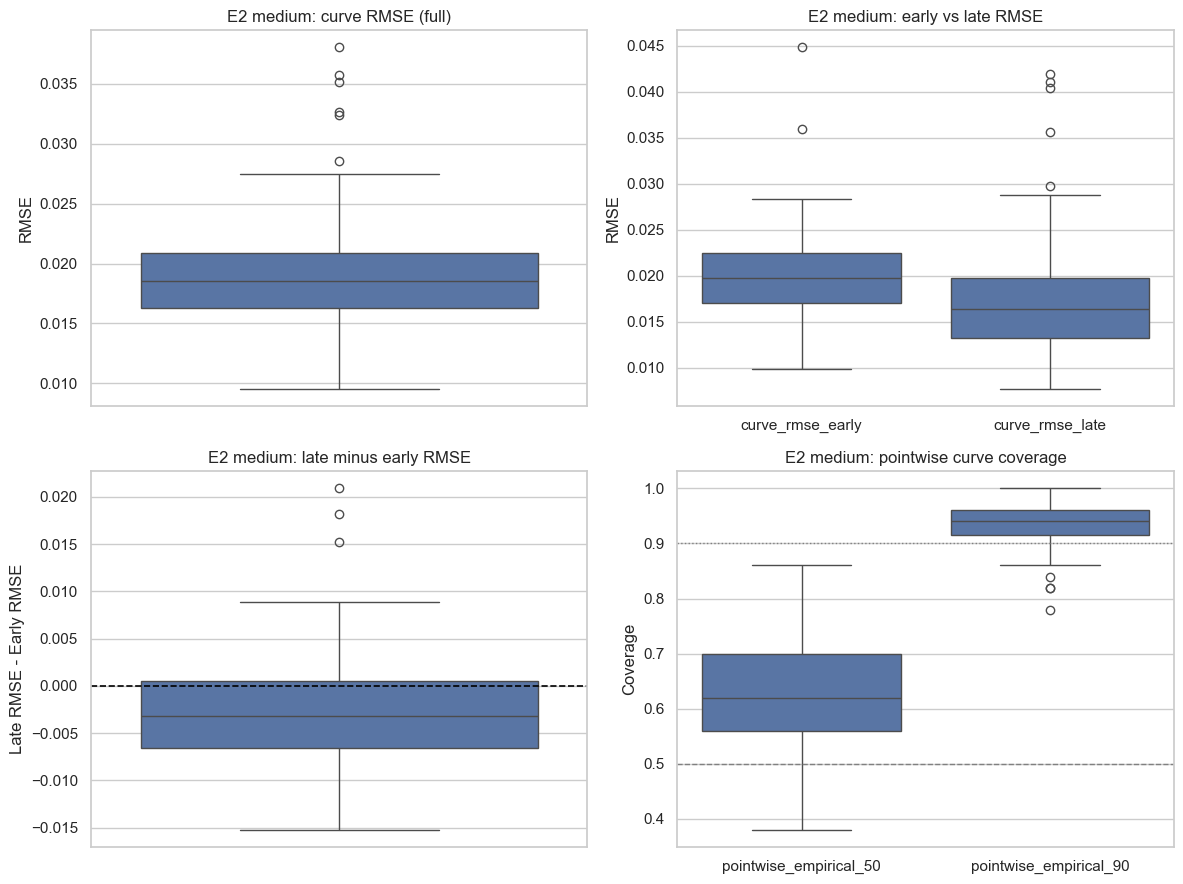


Curve-level PPC summary (E2 mild):


,metric,mean,std,median,q05,q95
0,pointwise_empirical_50,0.6330,0.1010,0.6400,0.4800,0.8210
1,pointwise_empirical_90,0.9338,0.0386,0.9400,0.8600,1.0000
2,curve_bias_full,-0.0034,0.0039,-0.0039,-0.0075,0.0031
3,curve_mae_full,0.0142,0.0034,0.0141,0.0081,0.0201
4,curve_rmse_full,0.0186,0.0035,0.0185,0.0124,0.0250
5,curve_bias_early,-0.0035,0.0043,-0.0038,-0.0097,0.0044
6,curve_mae_early,0.0154,0.0035,0.0160,0.0086,0.0202
7,curve_rmse_early,0.0195,0.0036,0.0197,0.0120,0.0249
8,curve_bias_late,-0.0033,0.0064,-0.0039,-0.0113,0.0090
9,curve_mae_late,0.0130,0.0045,0.0119,0.0069,0.0205



Curve-level PPC case head (E2 mild):


,case_id,pointwise_empirical_50,pointwise_empirical_90,curve_bias_full,curve_mae_full,curve_rmse_full,curve_bias_early,curve_mae_early,curve_rmse_early,curve_bias_late,...,late_minus_early_rmse,late_minus_early_mae,true_beta,true_gamma,true_R0,beta0,gamma,tau,kappa,severity
0,0,0.74,0.94,-0.0067,0.0113,0.0160,-0.0018,0.0086,0.0108,-0.0116,...,0.0090,0.0054,0.2448,0.3380,0.7243,0.2610,0.3380,17,0.9056,mild
1,1,0.50,0.90,0.0000,0.0184,0.0231,-0.0057,0.0176,0.0223,0.0057,...,0.0017,0.0015,0.3560,0.0938,3.7975,0.3843,0.0938,16,0.8919,mild
2,2,0.84,0.98,-0.0029,0.0079,0.0120,-0.0025,0.0089,0.0143,-0.0033,...,-0.0051,-0.0020,0.2680,0.4238,0.6325,0.2754,0.4238,17,0.9597,mild
3,3,0.60,0.90,-0.0040,0.0141,0.0189,-0.0073,0.0170,0.0223,-0.0007,...,-0.0075,-0.0058,0.4925,0.2087,2.3604,0.5088,0.2087,20,0.9466,mild
4,4,0.72,0.98,-0.0069,0.0113,0.0151,-0.0070,0.0119,0.0171,-0.0068,...,-0.0042,-0.0012,0.1665,0.1870,0.8902,0.1825,0.1870,20,0.8532,mild


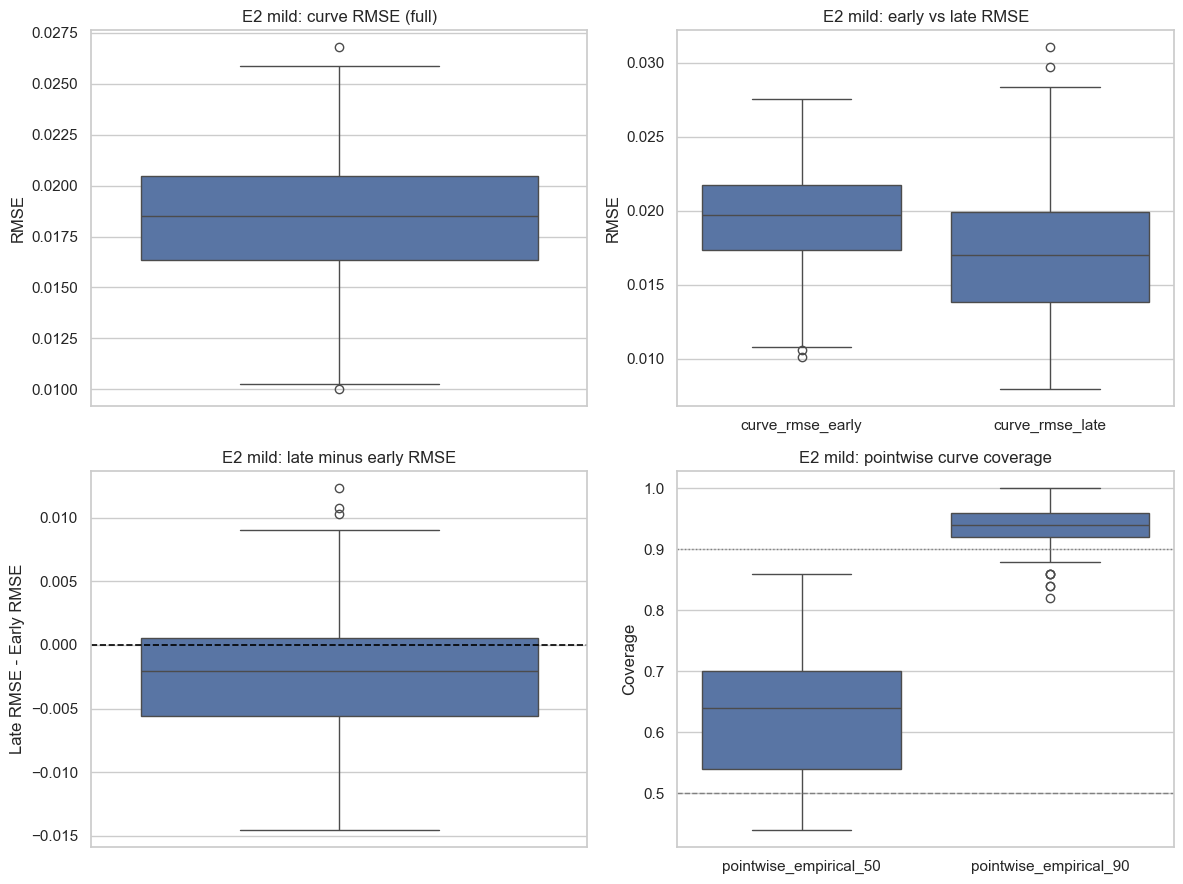


Curve-level PPC summary (E2 strong):


,metric,mean,std,median,q05,q95
0,pointwise_empirical_50,0.6292,0.1244,0.6400,0.3980,0.8210
1,pointwise_empirical_90,0.9132,0.0716,0.9200,0.8370,0.9800
2,curve_bias_full,-0.0023,0.0049,-0.0038,-0.0074,0.0073
3,curve_mae_full,0.0148,0.0060,0.0138,0.0081,0.0271
4,curve_rmse_full,0.0197,0.0072,0.0185,0.0124,0.0352
5,curve_bias_early,-0.0031,0.0054,-0.0034,-0.0101,0.0058
6,curve_mae_early,0.0165,0.0055,0.0159,0.0086,0.0245
7,curve_rmse_early,0.0211,0.0069,0.0198,0.0123,0.0296
8,curve_bias_late,-0.0015,0.0074,-0.0029,-0.0098,0.0127
9,curve_mae_late,0.0132,0.0078,0.0112,0.0066,0.0257



Curve-level PPC case head (E2 strong):


,case_id,pointwise_empirical_50,pointwise_empirical_90,curve_bias_full,curve_mae_full,curve_rmse_full,curve_bias_early,curve_mae_early,curve_rmse_early,curve_bias_late,...,late_minus_early_rmse,late_minus_early_mae,true_beta,true_gamma,true_R0,beta0,gamma,tau,kappa,severity
0,0,0.74,0.92,-0.0074,0.0113,0.0164,-0.0025,0.0086,0.0110,-0.0122,...,0.0093,0.0055,0.1596,0.3380,0.4722,0.2610,0.3380,17,0.4112,strong
1,1,0.30,0.78,0.0073,0.0297,0.0367,0.0081,0.0297,0.0377,0.0065,...,-0.0020,0.0000,0.2233,0.0938,2.3814,0.3843,0.0938,16,0.3839,strong
2,2,0.84,0.98,-0.0031,0.0079,0.0122,-0.0027,0.0090,0.0146,-0.0034,...,-0.0054,-0.0023,0.1880,0.4238,0.4436,0.2754,0.4238,17,0.5194,strong
3,3,0.54,0.84,-0.0039,0.0160,0.0218,-0.0103,0.0208,0.0269,0.0025,...,-0.0117,-0.0094,0.3541,0.2087,1.6969,0.5088,0.2087,20,0.4931,strong
4,4,0.74,0.98,-0.0067,0.0104,0.0144,-0.0077,0.0121,0.0171,-0.0056,...,-0.0061,-0.0032,0.1066,0.1870,0.5699,0.1825,0.1870,20,0.3064,strong


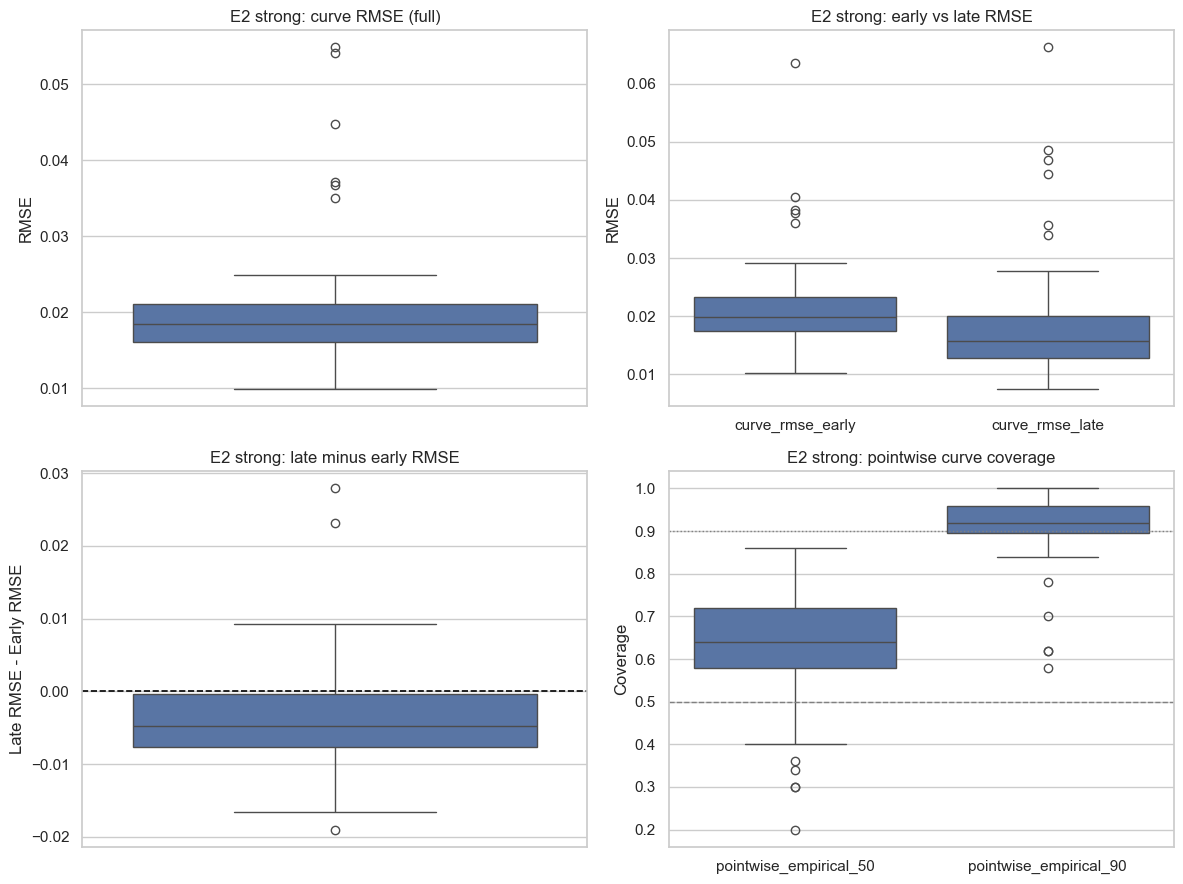

In [14]:
curve_outputs = {}
for severity in ["medium", "mild", "strong"]:
    curve_case_df, curve_summary_df = evaluate_curve_level_ppc(
        workflow=workflow_E0,
        case_simulator=lambda rng=None, sev=severity: simulate_case_E2(rng=rng, severity=sev),
        predictive_curve_simulator=simulate_curve,
        n_test=100,
        num_posterior_samples=1000,
        n_ppc_draws=100,
        seed=2026,
        split_frac=0.5,
    )
    curve_outputs[severity] = (curve_case_df, curve_summary_df)
    out_dir = OUTPUTS_ROOT / "E2" / "curve_level" / severity
    os.makedirs(out_dir, exist_ok=True)
    print(f"\nCurve-level PPC summary (E2 {severity}):")
    display(curve_summary_df.round(4))
    print(f"\nCurve-level PPC case head (E2 {severity}):")
    display(curve_case_df.head().round(4))
    plot_curve_level_ppc_summary(curve_case_df, severity_label=severity, out_dir=out_dir)
    curve_case_df.to_csv(out_dir / f"E2_curve_case_level_{severity}.csv", index=False)
    curve_summary_df.to_csv(out_dir / f"E2_curve_summary_{severity}.csv", index=False)

The curve-level PPC results show that, across the mild, medium, and strong misspecification settings, posterior predictive curves remain comparatively close to the observed trajectories, even when parameter-level posterior calibration deteriorates sharply. This pattern is visible both in the pointwise coverage metrics and in the full-curve discrepancy measures.

First, pointwise predictive coverage remains high across all three severities. The empirical 90% pointwise coverage is 0.9286 under mild misspecification, 0.9264 under medium misspecification, and 0.9142 under strong misspecification. The corresponding empirical 50% pointwise coverage values are 0.6188, 0.6138, and 0.6280. Thus, although there is some variation across settings, there is no monotonic collapse in pointwise curve coverage analogous to what is observed for the posterior intervals of the reference quantities β and R0. If anything, pointwise predictive uncertainty remains slightly conservative across the entire severity range.

Second, the overall discrepancy between the observed curve and the posterior predictive median curve remains small in all three settings. The full-curve RMSE is 0.0195 in the mild setting, 0.0203 in the medium setting, and 0.0200 in the strong setting. Likewise, the full-curve MAE remains stable at 0.0150, 0.0156, and 0.0151, respectively. The full-curve bias stays very close to zero throughout (-0.0011, -0.0006, -0.0015). These values are numerically small and comparable to the observation-noise scale, indicating that the predictive median curve remains reasonably close to the observed time series even under stronger misspecification.

Third, the early-versus-late window comparison does not reveal a systematic worsening in the later phase. The early-window RMSE is 0.0196, 0.0202, and 0.0210 for mild, medium, and strong misspecification, while the late-window RMSE is slightly smaller in all three cases: 0.0187, 0.0194, and 0.0182. This is reflected directly in late_minus_early_rmse, which is negative throughout: -0.0009 for mild, -0.0008 for medium, and -0.0029 for strong. The same qualitative pattern appears for MAE (late_minus_early_mae = -0.0011, -0.0008, -0.0028). Therefore, under the current early/late split and median-curve comparison, the curve-level discrepancy metrics do not support the claim that misspecification produces a clear late-phase predictive breakdown.

So, the curve-level PPC results reinforce the same broader conclusion already suggested by the feature-level PPC analyses: the main misspecification signal in E2 is not a dramatic failure to reproduce the observed epidemic curves, but a severe degradation in posterior reliability for the transmission-related reference quantities. Even under strong time-varying transmission misspecification, the inference model still generates predictive curves that remain broadly plausible according to the pointwise-coverage and median-curve discrepancy diagnostics used here. This means that, in the current E2 setting, misspecification is revealed much more clearly by parameter-level bias and under-coverage than by low-dimensional predictive summaries or whole-curve fit diagnostics.